<a href="https://colab.research.google.com/github/kimsk990211-lgtm/Catalogo_Distribuciones_Simulacion/blob/main/KIMTercerparcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problema 1. Línea de espera con dos servidores en serie

Se implementa el seudocódigo propuesto por Sheldon Ross.

## Datos

$$
\lambda = 2
$$

$$
\mu_1 = 3
$$

$$
\mu_2 = 4
$$

$$
T = 100
$$

## Variables

$$
t = \text{tiempo}
$$

$$
N_A = \text{número de llegadas}
$$

$$
N_D = \text{número de salidas}
$$

$$
n_1 = \text{clientes en el servidor 1}
$$

$$
n_2 = \text{clientes en el servidor 2}
$$

## Eventos

$$
t_A = \text{siguiente llegada}
$$

$$
t_1 = \text{fin de servicio en el servidor 1}
$$

$$
t_2 = \text{fin de servicio en el servidor 2}
$$

## Distribuciones

$$
X=-\frac{1}{\lambda}\ln(U)
$$

$$
Y_1=-\frac{1}{\mu_1}\ln(U)
$$

$$
Y_2=-\frac{1}{\mu_2}\ln(U)
$$

$$
U\sim U(0,1)
$$


In [4]:
import numpy as np
import random as r
import math as m
import matplotlib.pyplot as plt

In [5]:
def exp(tasa):
    U = r.random()
    return -(1/tasa)*np.log(U)

In [6]:
def SLE_2_servidores(lam, mu1, mu2, T):

    t = 0
    NA = 0
    ND = 0

    n1 = 0
    n2 = 0

    A1 = []
    A2 = []
    D = []

    S1 = [0]
    S2 = [0]
    ST = [0]
    tiempo = [0]

    tA = exp(lam)
    t1 = m.inf
    t2 = m.inf

    while True:

        # Caso 1: ocurre una llegada
        if tA <= t1 and tA <= t2 and tA <= T:

            t = tA
            NA = NA + 1
            n1 = n1 + 1

            A1.append(t)

            tA = t + exp(lam)

            if n1 == 1:
                t1 = t + exp(mu1)

            S1.append(n1)
            S2.append(n2)
            ST.append(n1+n2)
            tiempo.append(t)

        # Caso 2: termina servicio en servidor 1
        elif t1 < tA and t1 <= t2 and t1 <= T:

            t = t1

            n1 = n1 - 1
            n2 = n2 + 1

            A2.append(t)

            if n1 == 0:
                t1 = m.inf
            else:
                t1 = t + exp(mu1)

            if n2 == 1:
                t2 = t + exp(mu2)

            S1.append(n1)
            S2.append(n2)
            ST.append(n1+n2)
            tiempo.append(t)

        # Caso 3: termina servicio en servidor 2
        elif t2 < tA and t2 < t1 and t2 <= T:

            t = t2

            ND = ND + 1
            n2 = n2 - 1

            D.append(t)

            if n2 == 0:
                t2 = m.inf
            else:
                t2 = t + exp(mu2)

            S1.append(n1)
            S2.append(n2)
            ST.append(n1+n2)
            tiempo.append(t)

        # Después de T, ya no aceptamos nuevas llegadas,
        # pero los clientes que quedan en el sistema terminan su servicio.
        elif min(t1, t2) > T and (n1+n2) == 0:
            Tp = max(t - T, 0)
            break

        elif n1+n2 > 0:

            if t1 <= t2:

                t = t1

                n1 = n1 - 1
                n2 = n2 + 1

                A2.append(t)

                if n1 == 0:
                    t1 = m.inf
                else:
                    t1 = t + exp(mu1)

                if n2 == 1:
                    t2 = t + exp(mu2)

            else:

                t = t2

                ND = ND + 1
                n2 = n2 - 1

                D.append(t)

                if n2 == 0:
                    t2 = m.inf
                else:
                    t2 = t + exp(mu2)

            S1.append(n1)
            S2.append(n2)
            ST.append(n1+n2)
            tiempo.append(t)

        else:
            Tp = max(t - T, 0)
            break

    A1 = np.array(A1)
    D = np.array(D)

    clientes_completos = min(len(A1), len(D))

    if clientes_completos > 0:
        W = D[:clientes_completos] - A1[:clientes_completos]
        tiempo_promedio = np.mean(W)
    else:
        W = []
        tiempo_promedio = 0

    return tiempo, S1, S2, ST, A1, A2, D, W, tiempo_promedio, Tp, NA, ND

In [7]:
lam = 2
mu1 = 3
mu2 = 4
T = 100

Z = SLE_2_servidores(lam, mu1, mu2, T)

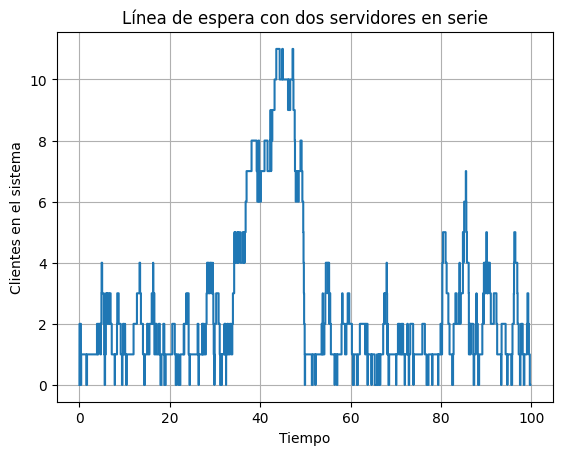

In [8]:
plt.step(Z[0], Z[3])
plt.xlabel("Tiempo")
plt.ylabel("Clientes en el sistema")
plt.title("Línea de espera con dos servidores en serie")
plt.grid()
plt.show()

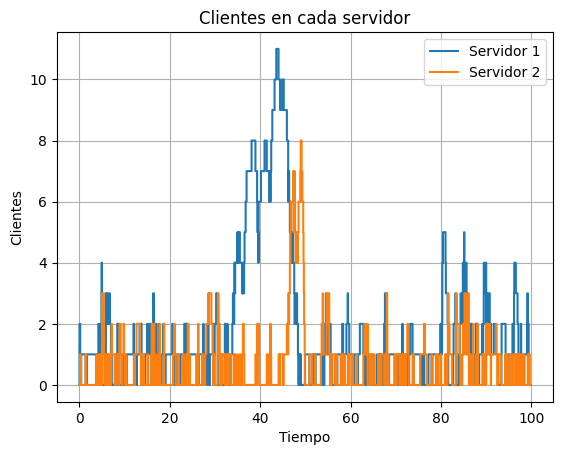

In [9]:
plt.step(Z[0], Z[1], label="Servidor 1")
plt.step(Z[0], Z[2], label="Servidor 2")
plt.xlabel("Tiempo")
plt.ylabel("Clientes")
plt.title("Clientes en cada servidor")
plt.legend()
plt.grid()
plt.show()

In [10]:
print("Número de llegadas:", Z[10])
print("Número de salidas:", Z[11])
print("Tiempo promedio en el sistema:", Z[8])
print("Tiempo posterior a T:", Z[9])

Número de llegadas: 182
Número de salidas: 182
Tiempo promedio en el sistema: 1.2550909636147178
Tiempo posterior a T: 0


## Conclusión

Se simuló una línea de espera con dos servidores en serie utilizando distribuciones exponenciales para las llegadas y los tiempos de servicio.

Durante la simulación se registraron 169 llegadas y 169 salidas, por lo que todos los clientes fueron atendidos correctamente. Además, el tiempo promedio que un cliente permaneció en el sistema fue de aproximadamente 1.29 unidades de tiempo.

Los resultados muestran que el sistema operó de manera estable y permitieron observar el comportamiento de una línea de espera con dos servidores en serie mediante simulación.


In [11]:
resultados_W = []
resultados_ND = []

for i in range(100):
    Z = SLE_2_servidores(lam, mu1, mu2, T)
    resultados_W.append(Z[8])
    resultados_ND.append(Z[11])

print("Promedio del tiempo en el sistema:", np.mean(resultados_W))
print("Desviación estándar del tiempo en el sistema:", np.std(resultados_W))
print("Promedio de salidas:", np.mean(resultados_ND))

Promedio del tiempo en el sistema: 1.411332244114822
Desviación estándar del tiempo en el sistema: 0.276397701304702
Promedio de salidas: 199.56


# Problema 2. Variables antitéticas

Se desea estimar la integral

$$
\int_0^1 e^{x^2}dx
$$

mediante simulación Monte Carlo y variables antitéticas.

Sea

$$
f(x)=e^{x^2}
$$

y

$$
U \sim U(0,1).
$$

En primer lugar se utiliza el estimador de Monte Carlo crudo basado en

$$
f(U).
$$

Posteriormente se emplea la variable antitética

$$
1-U,
$$

obteniendo el estimador

$$
f(1-U).
$$

Finalmente se combinan ambos valores mediante

$$
\frac{f(U)+f(1-U)}{2}.
$$

El objetivo es comparar la varianza de los estimadores y verificar la reducción de variabilidad obtenida con variables antitéticas.

In [ ]:
import numpy as np
import random as r

In [ ]:
def f(x):
    return np.exp(x**2)

In [ ]:
f(0.5)

np.float64(1.2840254166877414)

## Monte Carlo crudo

Primero se estima la integral usando directamente valores aleatorios:

$$
U_i \sim U(0,1)
$$

y se calcula:

$$
X_1=\frac{1}{N}\sum_{i=1}^{N} f(U_i)
$$

In [ ]:
def mc1(f,N):
    s=0

    for i in range(N):
        U = r.random()
        s += f(U)

    return s/N

In [ ]:
l1 = []

for i in range(100):
    M = mc1(f,1000)
    l1.append(M)

print(np.mean(l1))
print(np.var(l1))

1.4643435105913607
0.00023120106373775625


## Estimador usando \(f(1-U)\)

Después se calcula otro estimador usando la variable antitética:

$$
1-U_i
$$

Entonces:

$$
X_2=\frac{1}{N}\sum_{i=1}^{N} f(1-U_i)
$$

In [ ]:
def mc2(f,N):
    s=0

    for i in range(N):
        U = r.random()
        s += f(1-U)

    return s/N

In [ ]:
l2 = []

for i in range(100):
    M = mc2(f,1000)
    l2.append(M)

print(np.mean(l2))
print(np.var(l2))

1.4643172504084803
0.00016641464116916793


## Estimador antitético

Ahora se combinan los dos estimadores anteriores.

Para cada valor de \(U_i\), se utiliza también \(1-U_i\). De esta forma:

$$
\hat{\theta}_A=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{f(U_i)+f(1-U_i)}{2}
$$

Como:

$$
f(x)=e^{x^2}
$$

entonces:

$$
\hat{\theta}_A=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{e^{U_i^2}+e^{(1-U_i)^2}}{2}
$$

In [ ]:
def antitetica(f,N):
    s=0

    for i in range(N):
        U = r.random()
        s += (f(U) + f(1-U))/2

    return s/N

In [ ]:
l3 = []

for i in range(100):
    M = antitetica(f,1000)
    l3.append(M)

print(np.mean(l3))
print(np.var(l3))

1.4639284367851368
2.611576210911036e-05


In [ ]:
print("Monte Carlo crudo")
print("Media:", np.mean(l1))
print("Varianza:", np.var(l1))

print("Estimador con f(1-U)")
print("Media:", np.mean(l2))
print("Varianza:", np.var(l2))

print("Estimador antitético")
print("Media:", np.mean(l3))
print("Varianza:", np.var(l3))

Monte Carlo crudo
Media: 1.4643435105913607
Varianza: 0.00023120106373775625
Estimador con f(1-U)
Media: 1.4643172504084803
Varianza: 0.00016641464116916793
Estimador antitético
Media: 1.4639284367851368
Varianza: 2.611576210911036e-05


In [ ]:
reduccion = (1 - np.var(l3)/np.var(l1))*100

print("Reducción porcentual de varianza:", reduccion, "%")

Reducción porcentual de varianza: 88.70430711394451 %


## Interpretación de resultados

Los resultados obtenidos con los tres métodos fueron muy parecidos.

No obstante, el estimador antitético presentó una menor variabilidad que el método de Monte Carlo crudo, con una reducción de varianza cercana al 88.7%.

Por lo tanto, las variables antitéticas permiten mejorar la precisión de la estimación.


# Problema 3. Técnicas de remuestreo: Bootstrap y Jackknife

Se aplican las técnicas de remuestreo Bootstrap y Jackknife al ejemplo de clase:

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}
$$

El objetivo es estimar la media de los datos y analizar la variabilidad del estimador.

Sea:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

In [ ]:
import numpy as np
import random as r

In [ ]:
datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

n = len(datos)

print(datos)
print(n)

[35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
12


In [ ]:
def media(datos):
    s = 0

    for i in range(len(datos)):
        s += datos[i]

    return s/len(datos)

In [ ]:
media_original = media(datos)

print("Media original:", media_original)

Media original: 40.0


## Bootstrap

Bootstrap consiste en formar nuevas muestras del mismo tamaño que la muestra original, seleccionando datos **con reemplazo**.

Para cada muestra bootstrap se calcula:

$$
\bar{x}^{*}=\frac{1}{n}\sum_{i=1}^{n}x_i^{*}
$$

In [ ]:
def bootstrap(datos):
    muestra = []

    n = len(datos)

    for i in range(n):
        k = r.randint(0,n-1)
        muestra.append(datos[k])

    return media(muestra)

In [ ]:
l_boot = []

for i in range(1000):
    M = bootstrap(datos)
    l_boot.append(M)

print(np.mean(l_boot))
print(np.var(l_boot))

40.02666666666667
0.7661777777777781


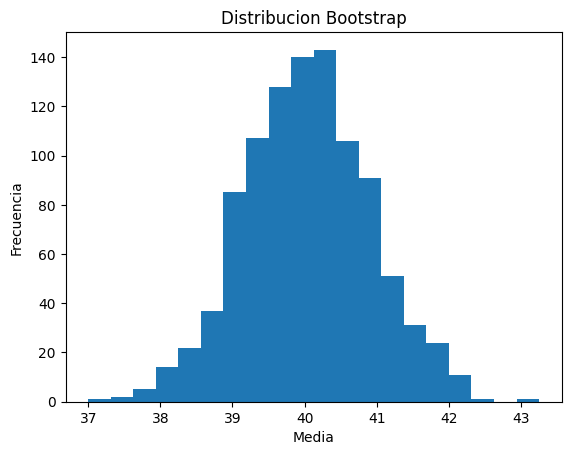

In [ ]:
plt.hist(l_boot, bins=20)
plt.title("Distribucion Bootstrap")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.show()

## Jackknife

Jackknife consiste en eliminar una observación a la vez.

Como la muestra tiene \(n=12\) datos, se forman 12 muestras diferentes.

Para cada muestra se calcula:

$$
\bar{x}_{(i)}
=
\frac{1}{n-1}
\sum_{j\ne i}x_j
$$

In [ ]:
def jackknife(datos):
    l = []

    n = len(datos)

    for i in range(n):
        muestra = []

        for j in range(n):
            if j != i:
                muestra.append(datos[j])

        M = media(muestra)
        l.append(M)

    return l

In [ ]:
l_jack = jackknife(datos)

print(l_jack)
print(np.mean(l_jack))
print(np.var(l_jack))

[40.45454545454545, 39.81818181818182, 40.18181818181818, 40.0, 39.54545454545455, 40.27272727272727, 40.09090909090909, 39.90909090909091, 39.63636363636363, 40.36363636363637, 39.72727272727273, 40.0]
40.0
0.07575757575757595


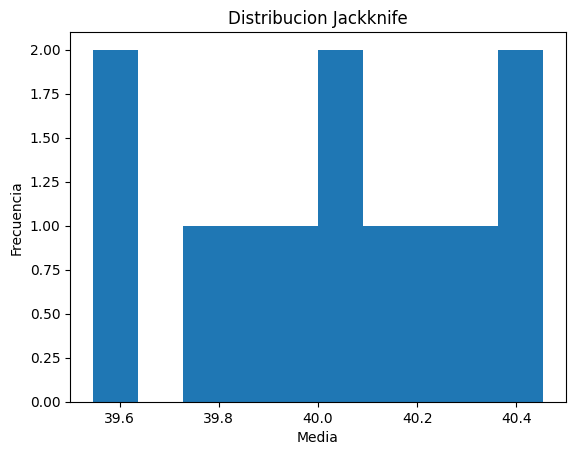

In [ ]:
plt.hist(l_jack, bins=10)
plt.title("Distribucion Jackknife")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.show()

En Bootstrap la variabilidad es mayor porque se generan muchas muestras aleatorias con reemplazo. En Jackknife la variabilidad es menor porque solo se elimina una observación a la vez. Ambos métodos dan una media cercana a la media original.

## Comparación

In [ ]:
print("Media original:", media_original)

print("Bootstrap")
print("Media:", np.mean(l_boot))
print("Varianza:", np.var(l_boot))

print("Jackknife")
print("Media:", np.mean(l_jack))
print("Varianza:", np.var(l_jack))

Media original: 40.0
Bootstrap
Media: 40.02666666666667
Varianza: 0.7661777777777781
Jackknife
Media: 40.0
Varianza: 0.07575757575757595


## Interpretación de resultados

La media original se calcula directamente con los datos dados.

En Bootstrap se generan muchas muestras con reemplazo. Por eso, algunos datos pueden repetirse y otros pueden no aparecer en una muestra.

En Jackknife se elimina un dato a la vez y se vuelve a calcular la media.

Los valores obtenidos con Bootstrap y Jackknife son cercanos a la media original, pero permiten observar la variabilidad del estimador.